In [1]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost

In [33]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load credit card dataset
df = pd.read_csv('creditcard.csv')

#Display information on dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (284807, 31)

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


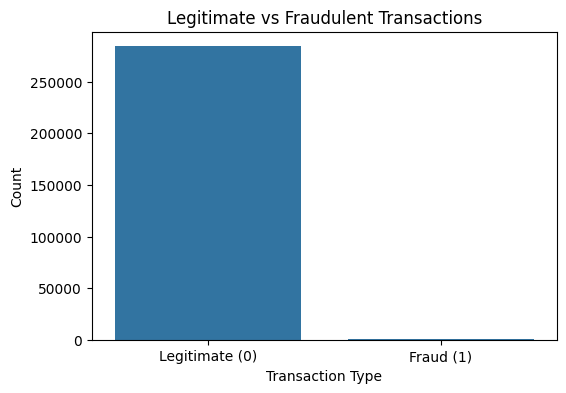

In [4]:
# Check the class distribution
print("Class Distribution:")
print(df['Class'].value_counts())
print("\nFraud Percentage:")
print(df['Class'].value_counts(normalize=True) * 100)

# Plot class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Legitimate vs Fraudulent Transactions')
plt.xticks([0,1], ['Legitimate (0)', 'Fraud (1)'])
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

In [5]:
# Check missing values and transaction amount statistics
print("Missing Values in Dataset:", df.isnull().sum().sum())

print("\nTransaction Amount Statistics:")
print(df['Amount'].describe())

print("\nAverage transaction amount by class:")
print(df.groupby('Class')['Amount'].mean())

Missing Values in Dataset: 0

Transaction Amount Statistics:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Average transaction amount by class:
Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64


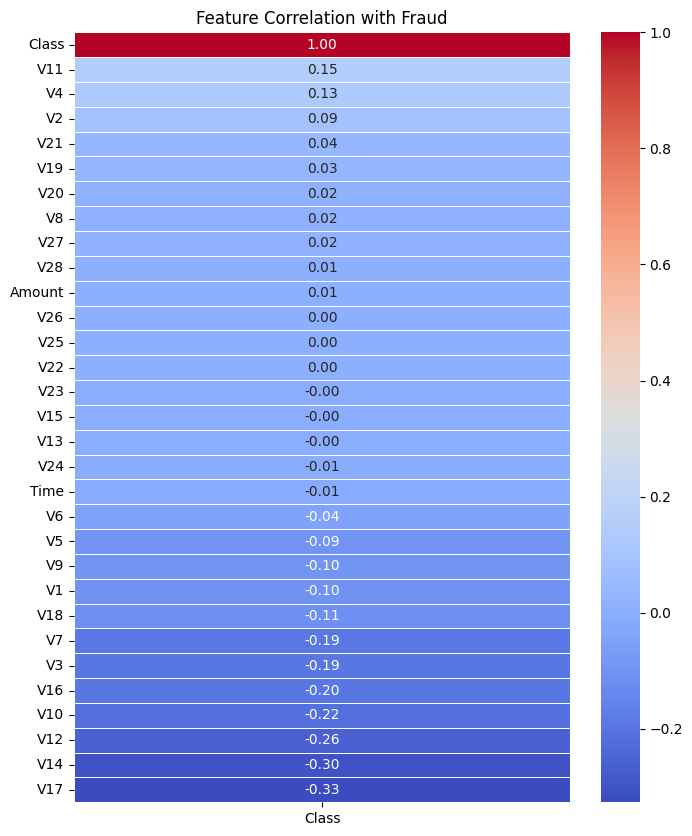

In [6]:
# Plot correlation between features and fraud
plt.figure(figsize=(8,10))
corr = df.corr()
sns.heatmap(corr[['Class']].sort_values('Class', ascending=False),
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation with Fraud')
plt.show()

In [7]:
# Split data into features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nFraud cases in training set:", y_train.sum())
print("Fraud cases in test set:", y_test.sum())

Training set size: (227845, 30)
Test set size: (56962, 30)

Fraud cases in training set: 394
Fraud cases in test set: 98


In [8]:
# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print("Fraud cases:", y_train.sum())
print("Legitimate cases:", (y_train == 0).sum())

print("\nAfter SMOTE:")
print("Fraud cases:", y_train_smote.sum())
print("Legitimate cases:", (y_train_smote == 0).sum())

Before SMOTE:
Fraud cases: 394
Legitimate cases: 227451

After SMOTE:
Fraud cases: 227451
Legitimate cases: 227451


In [34]:
# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote, y_train_smote)

# Make predictions on the test data set
lr_predictions = lr_model.predict(X_test)

print("\nLogistic Regression Results:")
print(classification_report(y_test, lr_predictions,
      target_names=['Legitimate', 'Fraud']))


Logistic Regression Results:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56864
       Fraud       0.12      0.90      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962



In [10]:
# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

# Make predictions on the test set
rf_predictions = rf_model.predict(X_test)

print("\nRandom Forest Results:")
print(classification_report(y_test, rf_predictions,
      target_names=['Legitimate', 'Fraud']))


Random Forest Results:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



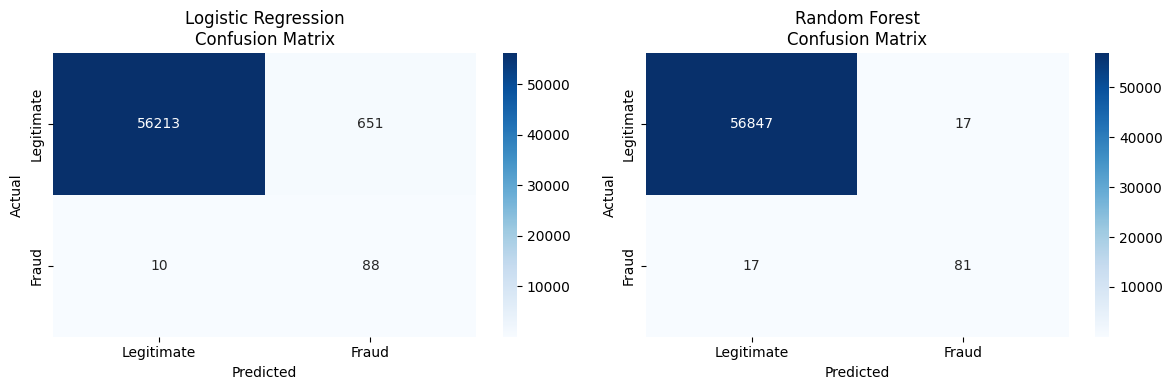

In [11]:
# Plot confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Logistic Regression confusion matrix
cm_lr = confusion_matrix(y_test, lr_predictions)
sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['Legitimate', 'Fraud'])
axes[0].set_yticklabels(['Legitimate', 'Fraud'])

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, rf_predictions)
sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[1], cmap='Blues')
axes[1].set_title('Random Forest\nConfusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['Legitimate', 'Fraud'])
axes[1].set_yticklabels(['Legitimate', 'Fraud'])

plt.tight_layout()
plt.show()

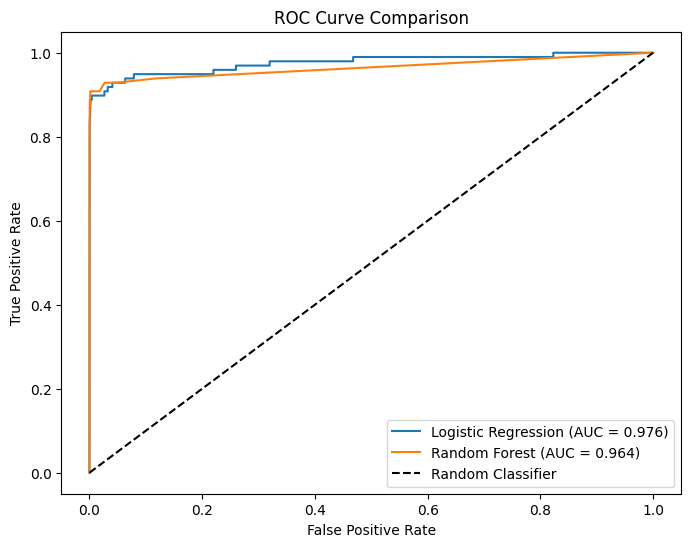

Logistic Regression AUC: 0.976
Random Forest AUC: 0.964


In [12]:
# Plot ROC curves for both models
lr_probs = lr_model.predict_proba(X_test)[:,1]
rf_probs = rf_model.predict_proba(X_test)[:,1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

plt.figure(figsize=(8,6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()
print(f"Logistic Regression AUC: {lr_auc:.3f}")
print(f"Random Forest AUC: {rf_auc:.3f}")

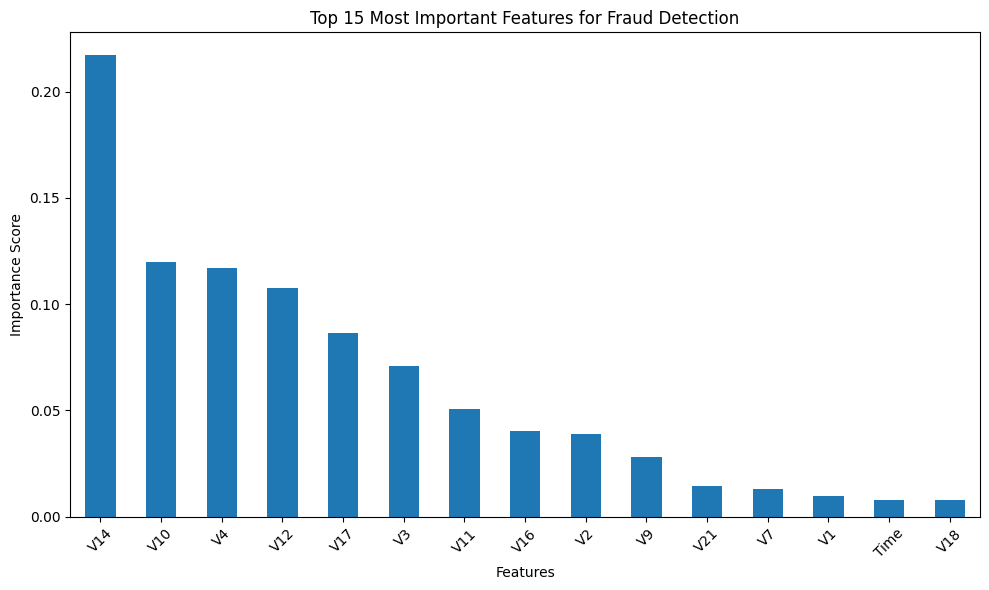

Top 5 most important features:
V14    0.216978
V10    0.119804
V4     0.116792
V12    0.107548
V17    0.086269
dtype: float64


In [13]:
# Plot Random Forest feature importance
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns).sort_values(ascending=False)[:15]

plt.figure(figsize=(10,6))
feature_importance.plot(kind='bar')
plt.title('Top 15 Most Important Features for Fraud Detection')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Top 5 most important features:")
print(feature_importance.head())

In [14]:
# Load PaySim dataset
df2 = pd.read_csv('PS_20174392719_1491204439457_log.csv')

print("PaySim Dataset Shape:", df2.shape)
print("\nColumn Names:")
print(df2.columns.tolist())
print("\nFirst 5 rows:")
df2.head()

PaySim Dataset Shape: (6362620, 11)

Column Names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


PaySim Fraud Distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Percentage:
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


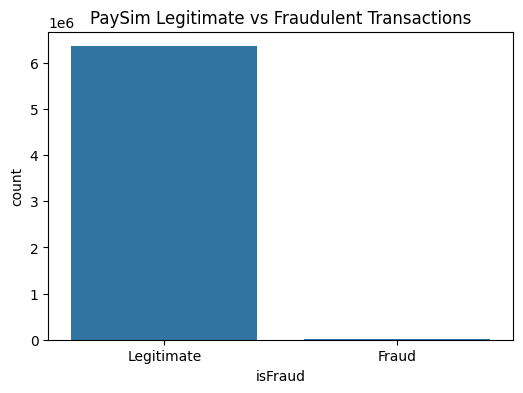

In [15]:
# Check PaySim class distribution
print("PaySim Fraud Distribution:")
print(df2['isFraud'].value_counts())
print("\nFraud Percentage:")
print(df2['isFraud'].value_counts(normalize=True) * 100)

# Plot PaySim class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df2)
plt.title('PaySim Legitimate vs Fraudulent Transactions')
plt.xticks([0,1], ['Legitimate', 'Fraud'])
plt.show()

In [16]:
# Prepare PaySim data for modelling
df2_clean = df2.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)
df2_clean = pd.get_dummies(df2_clean, columns=['type'])

X2 = df2_clean.drop('isFraud', axis=1)
y2 = df2_clean['isFraud']

print("PaySim features shape:", X2.shape)
print("Fraud cases:", y2.sum())

PaySim features shape: (6362620, 11)
Fraud cases: 8213


In [17]:
# Split PaySim data into training and test sets
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

print("PaySim Training set size:", X2_train.shape)
print("PaySim Test set size:", X2_test.shape)
print("\nFraud cases in training set:", y2_train.sum())
print("Fraud cases in test set:", y2_test.sum())

PaySim Training set size: (5090096, 11)
PaySim Test set size: (1272524, 11)

Fraud cases in training set: 6570
Fraud cases in test set: 1643


In [18]:
# Apply SMOTE to PaySim training data
smote2 = SMOTE(random_state=42)
X2_train_smote, y2_train_smote = smote2.fit_resample(X2_train, y2_train)

print("\nBefore SMOTE:")
print("Fraud cases:", y2_train.sum())
print("Legitimate cases:", (y2_train == 0).sum())

print("\nAfter SMOTE:")
print("Fraud cases:", y2_train_smote.sum())
print("Legitimate cases:", (y2_train_smote == 0).sum())


Before SMOTE:
Fraud cases: 6570
Legitimate cases: 5083526

After SMOTE:
Fraud cases: 5083526
Legitimate cases: 5083526


In [19]:
# Train Logistic Regression on PaySim data
lr_model2 = LogisticRegression(max_iter=1000, random_state=42)
lr_model2.fit(X2_train_smote, y2_train_smote)

lr_predictions2 = lr_model2.predict(X2_test)

print("\nPaySim Logistic Regression Results:")
print(classification_report(y2_test, lr_predictions2,
      target_names=['Legitimate', 'Fraud']))


PaySim Logistic Regression Results:
              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98   1270881
       Fraud       0.03      0.93      0.06      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.94      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524



In [20]:
# Train Random Forest on PaySim data
rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model2.fit(X2_train_smote, y2_train_smote)

rf_predictions2 = rf_model2.predict(X2_test)

print("\nPaySim Random Forest Results:")
print(classification_report(y2_test, rf_predictions2,
      target_names=['Legitimate', 'Fraud']))


PaySim Random Forest Results:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00   1270881
       Fraud       0.67      0.95      0.79      1643

    accuracy                           1.00   1272524
   macro avg       0.84      0.98      0.89   1272524
weighted avg       1.00      1.00      1.00   1272524



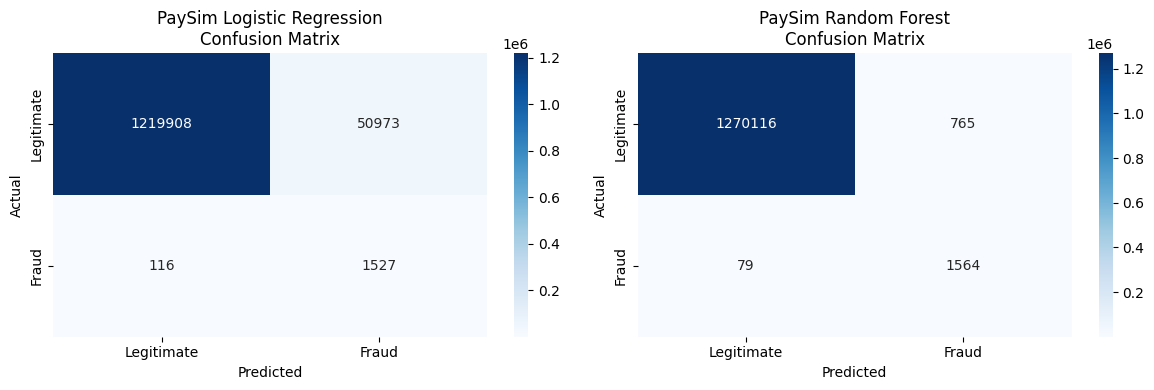

In [21]:
# Plot PaySim confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_lr2 = confusion_matrix(y2_test, lr_predictions2)
sns.heatmap(cm_lr2, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('PaySim Logistic Regression\nConfusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['Legitimate', 'Fraud'])
axes[0].set_yticklabels(['Legitimate', 'Fraud'])

cm_rf2 = confusion_matrix(y2_test, rf_predictions2)
sns.heatmap(cm_rf2, annot=True, fmt='d', ax=axes[1], cmap='Blues')
axes[1].set_title('PaySim Random Forest\nConfusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['Legitimate', 'Fraud'])
axes[1].set_yticklabels(['Legitimate', 'Fraud'])

plt.tight_layout()
plt.show()

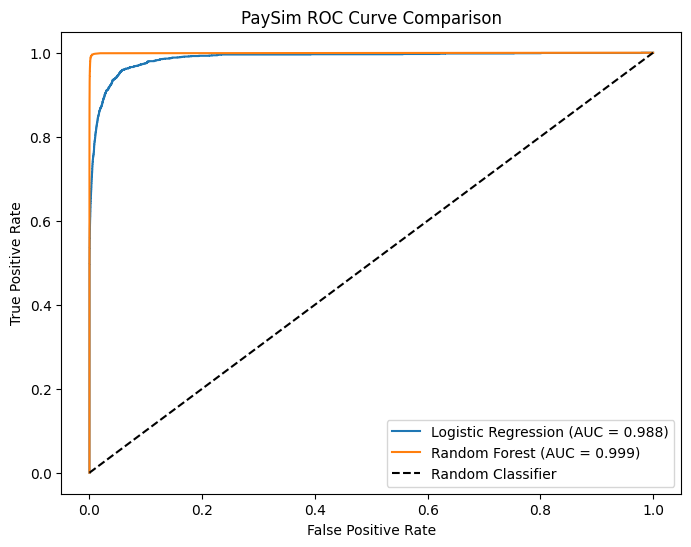

PaySim LR AUC: 0.988
PaySim RF AUC: 0.999


In [22]:
# Plot ROC curves for PaySim models
lr_probs2 = lr_model2.predict_proba(X2_test)[:,1]
rf_probs2 = rf_model2.predict_proba(X2_test)[:,1]

lr_fpr2, lr_tpr2, _ = roc_curve(y2_test, lr_probs2)
rf_fpr2, rf_tpr2, _ = roc_curve(y2_test, rf_probs2)

lr_auc2 = roc_auc_score(y2_test, lr_probs2)
rf_auc2 = roc_auc_score(y2_test, rf_probs2)

plt.figure(figsize=(8,6))
plt.plot(lr_fpr2, lr_tpr2, label=f'Logistic Regression (AUC = {lr_auc2:.3f})')
plt.plot(rf_fpr2, rf_tpr2, label=f'Random Forest (AUC = {rf_auc2:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('PaySim ROC Curve Comparison')
plt.legend()

plt.show()
print(f"PaySim LR AUC: {lr_auc2:.3f}")
print(f"PaySim RF AUC: {rf_auc2:.3f}")

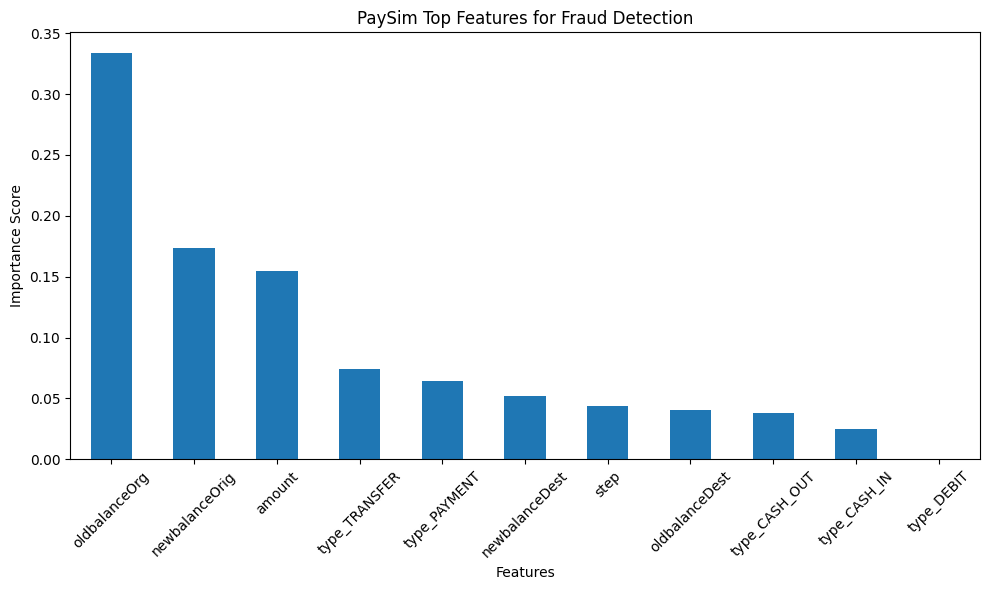

Top 5 most important features:
oldbalanceOrg     0.334053
newbalanceOrig    0.173212
amount            0.154535
type_TRANSFER     0.073735
type_PAYMENT      0.063907
dtype: float64


In [23]:
# Plot PaySim Random Forest feature importance
feature_importance2 = pd.Series(
    rf_model2.feature_importances_,
    index=X2.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance2.plot(kind='bar')
plt.title('PaySim Top Features for Fraud Detection')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Top 5 most important features:")
print(feature_importance2.head())

In [24]:
# Train XGBoost on credit card data
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train_smote, y_train_smote)
xgb_predictions = xgb_model.predict(X_test)

print("\nXGBoost Results - Credit Card:")
print(classification_report(y_test, xgb_predictions,
    target_names=['Legitimate', 'Fraud']))


XGBoost Results - Credit Card:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.79      0.85      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962



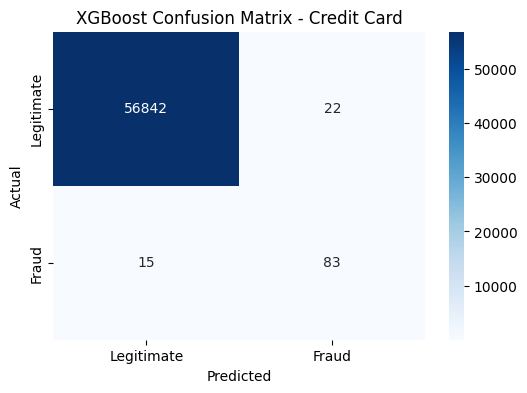

XGBoost AUC: 0.983


In [25]:
# Plot XGBoost confusion matrix and calculate AUC

cm_xgb = confusion_matrix(y_test, xgb_predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix - Credit Card')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5,1.5], ['Legitimate', 'Fraud'])
plt.yticks([0.5,1.5], ['Legitimate', 'Fraud'])
plt.show()

xgb_probs = xgb_model.predict_proba(X_test)[:,1]
xgb_auc = roc_auc_score(y_test, xgb_probs)
print(f"XGBoost AUC: {xgb_auc:.3f}")

In [26]:
# Train XGBoost on PaySim data

print("Training XGBoost model on PaySim dataset...")
xgb_model2 = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model2.fit(X2_train_smote, y2_train_smote)
xgb_predictions2 = xgb_model2.predict(X2_test)

print("\nXGBoost Results - PaySim:")
print(classification_report(y2_test, xgb_predictions2,
    target_names=['Legitimate', 'Fraud']))

Training XGBoost model on PaySim dataset...

XGBoost Results - PaySim:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00   1270881
       Fraud       0.36      0.99      0.53      1643

    accuracy                           1.00   1272524
   macro avg       0.68      1.00      0.76   1272524
weighted avg       1.00      1.00      1.00   1272524



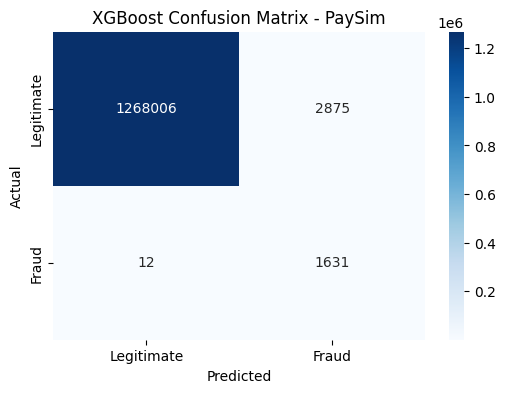

XGBoost AUC: 0.999


In [27]:
# Plot PaySim XGBoost confusion matrix and calculate AUC

cm_xgb2 = confusion_matrix(y2_test, xgb_predictions2)
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb2, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix - PaySim')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5,1.5], ['Legitimate', 'Fraud'])
plt.yticks([0.5,1.5], ['Legitimate', 'Fraud'])
plt.show()

xgb_probs2 = xgb_model2.predict_proba(X2_test)[:,1]
xgb_auc2 = roc_auc_score(y2_test, xgb_probs2)
print(f"XGBoost AUC: {xgb_auc2:.3f}")

In [35]:
# Run 5-fold stratified cross-validation on the credit card dataset

from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression cross validation
lr_cv = LogisticRegression(max_iter=1000, random_state=42)
lr_cv_scores = cross_val_score(lr_cv, X_train, y_train,
    cv=cv, scoring='f1')

print("\nLogistic Regression 5-Fold CV F1 Scores:")
print(lr_cv_scores)
print(f"Mean F1: {lr_cv_scores.mean():.3f} (+/- {lr_cv_scores.std():.3f})")

# Random Forest cross validation
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_cv_scores = cross_val_score(rf_cv, X_train, y_train,
    cv=cv, scoring='f1')

print("\nRandom Forest 5-Fold CV F1 Scores:")
print(rf_cv_scores)
print(f"Mean F1: {rf_cv_scores.mean():.3f} (+/- {rf_cv_scores.std():.3f})")


Logistic Regression 5-Fold CV F1 Scores:
[0.7518797  0.73134328 0.75862069 0.67175573 0.68656716]
Mean F1: 0.720 (+/- 0.035)

Random Forest 5-Fold CV F1 Scores:
[0.84285714 0.86330935 0.83916084 0.85526316 0.85314685]
Mean F1: 0.851 (+/- 0.009)


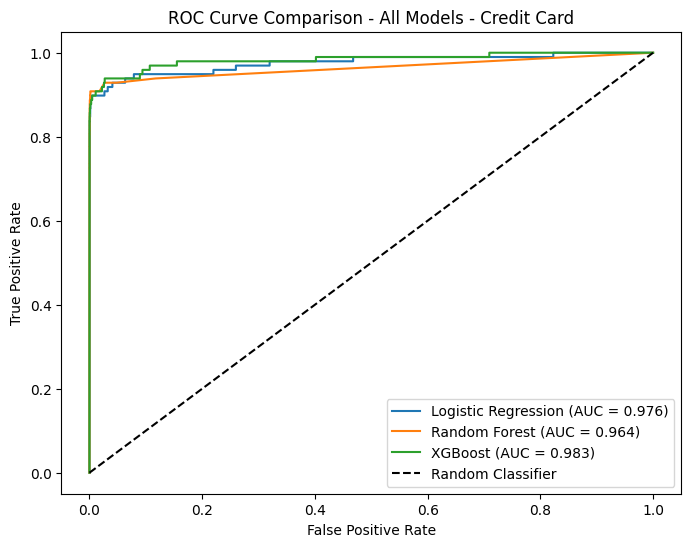

In [29]:
# Plot combined ROC curve for all credit card models
lr_probs = lr_model.predict_proba(X_test)[:,1]
rf_probs = rf_model.predict_proba(X_test)[:,1]
xgb_probs = xgb_model.predict_proba(X_test)[:,1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)

plt.figure(figsize=(8,6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - All Models - Credit Card')
plt.legend()
plt.show()

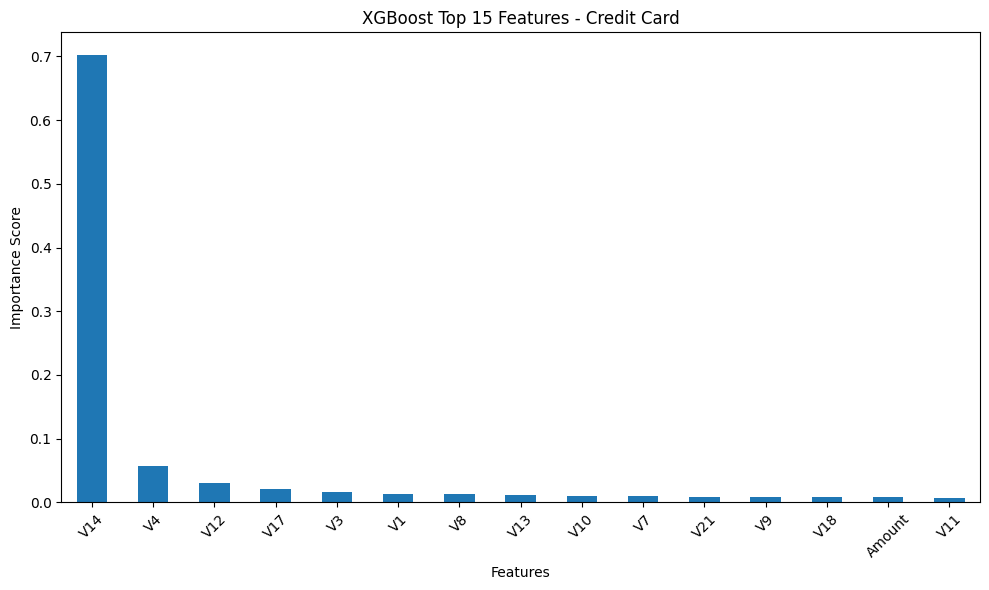

XGBoost Top 5 features:
V14    0.702731
V4     0.056232
V12    0.030155
V17    0.020600
V3     0.015473
dtype: float32


In [30]:
# Plot XGBoost feature importance for credit card data
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns).sort_values(ascending=False)[:15]

plt.figure(figsize=(10,6))
xgb_importance.plot(kind='bar')
plt.title('XGBoost Top 15 Features - Credit Card')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("XGBoost Top 5 features:")
print(xgb_importance.head())

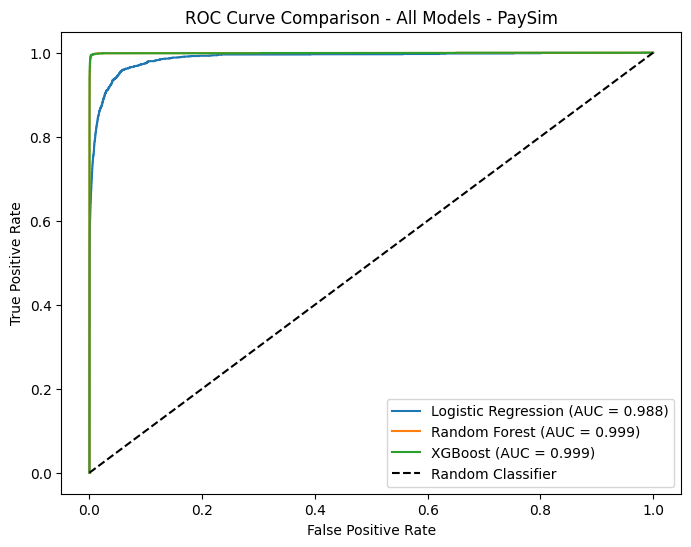

In [31]:
# Plot combined ROC curve for all PaySim models
lr_probs2 = lr_model2.predict_proba(X2_test)[:,1]
rf_probs2 = rf_model2.predict_proba(X2_test)[:,1]
xgb_probs2 = xgb_model2.predict_proba(X2_test)[:,1]

lr_fpr2, lr_tpr2, _ = roc_curve(y2_test, lr_probs2)
rf_fpr2, rf_tpr2, _ = roc_curve(y2_test, rf_probs2)
xgb_fpr2, xgb_tpr2, _ = roc_curve(y2_test, xgb_probs2)

lr_auc2 = roc_auc_score(y2_test, lr_probs2)
rf_auc2 = roc_auc_score(y2_test, rf_probs2)
xgb_auc2 = roc_auc_score(y2_test, xgb_probs2)

plt.figure(figsize=(8,6))
plt.plot(lr_fpr2, lr_tpr2, label=f'Logistic Regression (AUC = {lr_auc2:.3f})')
plt.plot(rf_fpr2, rf_tpr2, label=f'Random Forest (AUC = {rf_auc2:.3f})')
plt.plot(xgb_fpr2, xgb_tpr2, label=f'XGBoost (AUC = {xgb_auc2:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - All Models - PaySim')
plt.legend()
plt.show()

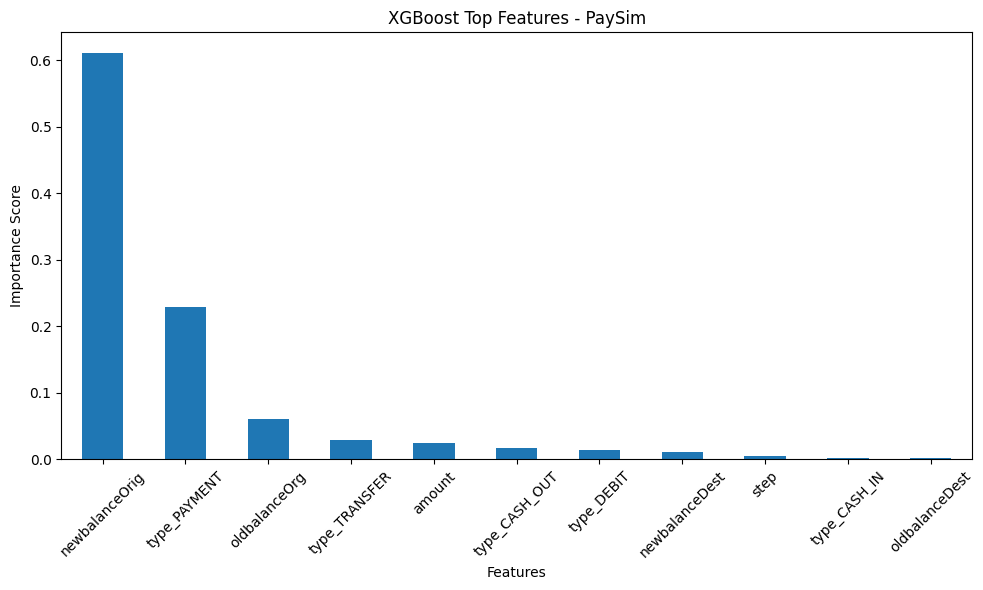

XGBoost PaySim Top features:
newbalanceOrig    0.611042
type_PAYMENT      0.228289
oldbalanceOrg     0.060389
type_TRANSFER     0.028296
amount            0.024188
dtype: float32


In [32]:
# Plot XGBoost feature importance for PaySim data
xgb_importance2 = pd.Series(
    xgb_model2.feature_importances_,
    index=X2.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
xgb_importance2.plot(kind='bar')
plt.title('XGBoost Top Features - PaySim')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("XGBoost PaySim Top features:")
print(xgb_importance2.head())